# IMT 573 - Problem Set 7 - Regression

### Instructions

Before beginning this assignment, please ensure you have access to a working instance of Jupyter Notebooks with Python 3.

1. First, replace the “YOUR NAME HERE” text in the next cell with your own full name. Any collaborators must also be listed in this cell.

2. Be sure to include well-documented (e.g. commented) code cells, figures, and clearly written text  explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy – you do no need four different visualizations of the same pattern.

3. Collaboration on problem sets and labs is fun, useful, and encouraged. However, each student must turn in an individual write-up in their own words as well as code/work that is their own. Regardless of whether you work with others, what you turn in must be your own work; this includes code and interpretation of results. The names of all collaborators must be listed on each assignment. Do not copy-and-paste from other students’ responses or code - your code should never be on any other student's screen or machine.

4. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

5. Partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown. Students are *strongly* encouraged to attempt each question and document their reasoning process even if they cannot find the correct answer. 

6. After completing the assignment, ensure that your code can run from start to finish without issue. Restart the kernal and run all cells to double check.

Name: Anika Mohan

Collaborators: 

Sources:

Used Perplexity Pro and outside sources along with class notes to improve my understanding of:
* https://seaborn.pydata.org/generated/seaborn.residplot.html
* https://seaborn.pydata.org/examples/residplot.html
* Data Aggregation- grouping the data at census tracts and across year levels. 
* Fitting a simple regression model for each explanatory variable to predict crime count and interpretting the regression coefs and pvalues  (using .pvalues to retrieve the p value) 

For this assignment, you'll need (at least) the following packages. If the package does not load, be sure it is properly installed.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

Previously, we examined police beat data joined with census tracts. In this problem set, we will perform regression analysis on this data.



### Problem 1: Load and examine crime data

#### (a) Load the beat and census data

You'll find a trimmed version of the beats and census data in the `census_beat_data_trimmed.csv` file. Load this data into a DataFrame. Note the variables in the data set.

In [18]:
census_data = pd.read_csv('census_beat_data_trimmed.csv')
print(census_data.columns)
census_data

Index(['geo_id', 'pri_offense_desc', 'year', 'pop_18_24', 'pop_25_over',
       'ed_high_sch_grad_higher_25_over', 'ed_bach_deg_grad_higher_25_over'],
      dtype='object')


,geo_id,pri_offense_desc,year,pop_18_24,pop_25_over,ed_high_sch_grad_higher_25_over,ed_bach_deg_grad_higher_25_over
0,1400000US53033009200,NARC-POSSESS-MARIJU,2012,118,2557,2106,985
1,1400000US53033003202,ROBBERY-BUSINESS-GUN,2012,181,3656,3656,2506
2,1400000US53033004600,VEH-THEFT-AUTO,2012,224,2690,2646,2111
3,1400000US53033008600,DUI-LIQUOR,2012,2975,3436,3316,2154
4,1400000US53033007502,ROBBERY-RESIDENCE-BODYFORCE,2012,322,2247,2247,1781
...,...,...,...,...,...,...,...
347975,1400000US53033010900,CHILD-OTHER,2019,20,935,880,433
347976,1400000US53033007502,BURGLARY-FORCE-RES,2019,322,2247,2247,1781
347977,1400000US53033011801,ROBBERY-BUSINESS-BODYFORCE,2019,432,2406,1990,976
347978,1400000US53033001100,THEFT-SHOPLIFT,2019,150,2089,2002,1463


#### (b) Examine years in data

Next, examine the years that are present in the dataset. Does it look as though there are years with incomplete or missing data? Filter the data such that it only contains data from the years 2016-2018 (inclusive).

In [19]:
print(sorted(census_data['year'].unique()))
print(census_data['year'].value_counts().sort_index())
yrs_filtered = census_data[(census_data['year'] >= 2016) & (census_data['year'] <= 2018)].copy()
yrs_filtered.head()

[np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
year
2012    40768
2013    45259
2014    49101
2015    47491
2016    48957
2017    49959
2018    50922
2019    15523
Name: count, dtype: int64


,geo_id,pri_offense_desc,year,pop_18_24,pop_25_over,ed_high_sch_grad_higher_25_over,ed_bach_deg_grad_higher_25_over
181960,1400000US53033011401,THEFT-OTH,2016,606,3640,3315,1299
181961,1400000US53033001100,THEFT-SHOPLIFT,2016,150,2089,2002,1463
181962,1400000US53033009000,THEFT-CARPROWL,2016,313,2993,2754,1559
181963,1400000US53033005402,THEFT-SHOPLIFT,2016,454,2601,2563,2046
181964,1400000US53033006702,THEFT-BUILDING,2016,144,2690,2690,2232


-----> It appears that most of the years from 2012 up until 2018 contain roughly the same amount of observations except for 2019 which has a significant less amount of observations which makes me believe there are some missing or invalid data that year. 


### Problem 2: Filter and create variables

#### (a) Examine crime types

For this analysis, we will limit the data to only include crimes of interest. The `pri_offense_desc` variable in the dataset refers to a description of the primary offense in the crimes dataset. This description contains a broad categorization of the crime followed by more specific cateogorizations (separated by hyphens). What are the five most common types of crime in the dataset based only on the broadest cateogorization (i.e. examining categories before the first hyphen)? 

In [20]:
# need to extract the broad category from the beginning of each string to find the top five most common crime types
census_data['crime_type'] = census_data['pri_offense_desc'].str.split('-').str[0]
top_five = census_data['crime_type'].value_counts().head(5)
print(top_five)

crime_type
THEFT       189238
BURGLARY     54111
VEH          29709
ASSLT        15821
TRESPASS     14362
Name: count, dtype: int64


-----> Top 5 most common types of crime in the dataset: Theft, Burglary, Veh, Asslt, Trespass 

#### (b) Filter by crime type

Filter the data so that it only contains the top-3 most frequent of the (broadest) crime categorizations. What are the dimensions of the dataset?

In [21]:
top_3 = census_data['crime_type'].value_counts().head(3)
print(top_3)
filter_top3 = census_data[census_data['crime_type'].isin(top_3.index)].copy()
filter_top3.shape

crime_type
THEFT       189238
BURGLARY     54111
VEH          29709
Name: count, dtype: int64


(273058, 8)

----> Dimensions: 273058 rows and 8 columns

#### (c) Aggregate data

The unit of observation in the crime/census data is individual crimes. We want to analyze the data at the census tract level. That necessitates aggregating the data for each of the census tracts. You may remember we had joined the census data to the crime data for non-specific years (i.e. the data was duplicated across years). To start, create a DataFrame of aggregated data named `data_agg` that has the following columns: 

- `geo_id` (which you will aggregate by), 
- `year` (which you will aggregate by), 
- `pop_18_24` (which can be duplicated for each `geo_id`/`year` combination)
- `pop_25_over` (which can be duplicated for each `geo_id`/`year` combination)
- `ed_high_sch_grad_higher_25_over` (which can be duplicated for each `geo_id`/`year` combination)
- `ed_bach_deg_grad_higher_25_over` (which can be duplicated for each `geo_id`/`year` combination)
- `num_crimes` (which will be a count of the number of crimes per `geo_id`/`year` combination)

In [22]:
data_agg = census_data.groupby(['geo_id', 'year']).agg(
    num_crimes=('pri_offense_desc', 'count'),
    pop_18_24 = ('pop_18_24', 'first'),
    pop_25_over = ('pop_25_over', 'first'),
    ed_high_sch_grad_higher_25_over = ('ed_high_sch_grad_higher_25_over', 'first'),
    ed_bach_deg_grad_higher_25_over = ('ed_bach_deg_grad_higher_25_over', 'first')).reset_index()

In [23]:
data_agg

,geo_id,year,num_crimes,pop_18_24,pop_25_over,ed_high_sch_grad_higher_25_over,ed_bach_deg_grad_higher_25_over
0,1400000US53033000202,2012,695,228,3194,2938,1910
1,1400000US53033000202,2013,872,228,3194,2938,1910
2,1400000US53033000202,2014,831,228,3194,2938,1910
3,1400000US53033000202,2015,733,228,3194,2938,1910
4,1400000US53033000202,2016,793,228,3194,2938,1910
...,...,...,...,...,...,...,...
395,1400000US53033011901,2015,798,195,3115,2679,992
396,1400000US53033011901,2016,816,195,3115,2679,992
397,1400000US53033011901,2017,752,195,3115,2679,992
398,1400000US53033011901,2018,846,195,3115,2679,992


#### (d) Calculate proportions

The `ed_high_sch_grad_higher_25_over` and `ed_bach_deg_grad_higher_25_over` variables refer to counts from the population. Create normalized versions of these variables named `high_sch_grad_prop` and `coll_grad_prop` that are normalized by the population that is 25 years and older in each tract.

In [24]:
print(data_agg.columns)


Index(['geo_id', 'year', 'num_crimes', 'pop_18_24', 'pop_25_over',
       'ed_high_sch_grad_higher_25_over', 'ed_bach_deg_grad_higher_25_over'],
      dtype='object')


In [25]:
data_agg['high_sch_grad_prop'] = data_agg['ed_high_sch_grad_higher_25_over'] / data_agg['pop_25_over']

data_agg['coll_grad_prop'] = data_agg['ed_bach_deg_grad_higher_25_over'] / data_agg['pop_25_over']

### Problem 3: Integrate household data

#### (a) Load and examine data

The `household_data.csv` file contains data on the number of households and the number of households with children for the census tracts of interest. Load the data and examine the distributions of the variables (not including `geo_id`).

In [26]:
household_data = pd.read_csv('household_data.csv')

print(household_data.head())

print(household_data.describe())


                 geo_id  num_hholds  num_hholds_with_child
0  1400000US53033000202        1651                    450
1  1400000US53033000602        1682                    381
2  1400000US53033001100        1086                    267
3  1400000US53033001201        1968                    284
4  1400000US53033001400        2329                    565
        num_hholds  num_hholds_with_child
count    50.000000               50.00000
mean   1977.820000              345.78000
std     585.198054              215.01175
min      86.000000                6.00000
25%    1674.500000              132.50000
50%    1945.500000              378.00000
75%    2308.500000              528.25000
max    3164.000000              831.00000


#### (b) Join datasets

Join the `data_agg` DataFrame and the household data using `geo_id`. Note that we will duplicate the data on households for each `geo_id` across the years in `data_agg`. Name the resulting dataset `data_reg`. What are the dimensions of `data_reg`?

In [27]:
data_reg = pd.merge(data_agg, household_data, on='geo_id', how='left')

print(data_reg.shape)

(400, 11)


---> the merged dataset has dimensions of 400 rows and 11 columns

## Problem 4: Regression

#### (a) Simple linear regression

Use the `data_reg` data and the following explanatory variables to fit simple linear regression models to predict the number of crimes in a tract: 

- year
- pop_18_24	
- pop_25_over
- ed_high_sch_grad_higher_25_over	
- ed_bach_deg_grad_higher_25_over	
- high_sch_grad_prop	
- coll_grad_prop	
- num_hholds	
- num_hholds_with_child

In which of the models is there a statistically significant association between the predictor and the response? Why do you think this is?

HINT: It may help to iterate using a for loop and storing the results from each model. Then, you can combine the results from each model to examine/compare. 

In [28]:

predict_vars = [
    'year',
    'pop_18_24',
    'pop_25_over',
    'ed_high_sch_grad_higher_25_over',
    'ed_bach_deg_grad_higher_25_over',
    'high_sch_grad_prop',
    'coll_grad_prop',
    'num_hholds',
    'num_hholds_with_child'
]

results = []

for var in predict_vars:
    X = sm.add_constant(data_reg[var])
    y = data_reg['num_crimes']

    model = sm.OLS(y, X).fit()
    results.append({
        'variable': var,
        'coef': model.params[var],
        'p_value': model.pvalues[var]
    })

#print(results)

#sort those with p-value < 0.05
results_df = pd.DataFrame(results)
print(results_df)
sig = results_df[results_df['p_value'] < 0.05]
print(sig)

                          variable        coef       p_value
0                             year  -34.371429  1.600938e-05
1                        pop_18_24    0.027825  3.669740e-01
2                      pop_25_over   -0.053882  1.772714e-03
3  ed_high_sch_grad_higher_25_over   -0.040419  2.147350e-02
4  ed_bach_deg_grad_higher_25_over   -0.012769  5.373215e-01
5               high_sch_grad_prop  853.257401  2.550706e-03
6                   coll_grad_prop  364.933152  1.350118e-03
7                       num_hholds   -0.016360  6.077614e-01
8            num_hholds_with_child   -0.425998  6.142696e-07
                          variable        coef       p_value
0                             year  -34.371429  1.600938e-05
2                      pop_25_over   -0.053882  1.772714e-03
3  ed_high_sch_grad_higher_25_over   -0.040419  2.147350e-02
5               high_sch_grad_prop  853.257401  2.550706e-03
6                   coll_grad_prop  364.933152  1.350118e-03
8            num_hholds_

----> The output above provides regression coefficients and p-values for each of the variable predictors and by sorting out the ones with p-value < 0.05, we can see which ones are statistically significant predictors of the number of crimes are: year, pop_25_over, ed_high_sch_grad_higher_25_over, high_sch_grad_prop, coll_grad_prop, and num_hholds_with_child

#### (b) Multiple regression

Fit a multiple regression model to predict the response using all of the predictors from the previous section. Describe your results. For which predictors can we reject the null hypothesis $H_0: \beta_j = 0$? Are these the same from the previous section? Explain what may be going on.

In [29]:
X = sm.add_constant(data_reg[predict_vars])
y = data_reg['num_crimes']

multi_reg = sm.OLS(y, X).fit()
print(multi_reg.summary())

                            OLS Regression Results                            
Dep. Variable:             num_crimes   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     8.621
Date:                Wed, 19 Nov 2025   Prob (F-statistic):           8.13e-12
Time:                        19:13:43   Log-Likelihood:                -2894.8
No. Observations:                 400   AIC:                             5810.
Df Residuals:                     390   BIC:                             5849.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

In [30]:
sig_pvalue = multi_reg.pvalues
print(sig_pvalue)

const                              0.000002
year                               0.000005
pop_18_24                          0.400564
pop_25_over                        0.005803
ed_high_sch_grad_higher_25_over    0.000685
ed_bach_deg_grad_higher_25_over    0.000542
high_sch_grad_prop                 0.007182
coll_grad_prop                     0.000472
num_hholds                         0.422048
num_hholds_with_child              0.000252
dtype: float64


----> The predictors we can reject the null hypothesis are the ones with a p-value < 0.05 (alpha). In this case, it would be all of them except for pop_18_24 and num_hholds as their p-value is greater than 0.05, making it not significant. Compared to the single regression model, there were 3 predictors that weren't found to be significant (pop_18_24, num_hholds, and ed_bach_deg_grad_higher_25_over). 


#### (c) Interpret relationships

For each of the variables in the multivariate regression model, interpret the relationship between the explanatory variable and the response variable based on the calculated coefficient. Do the relationships make sense to you? What are possible explanations about the observed coefficients?

1. Year with coef: -34.37
While holding all variables constant, the amount of crimes decrease by approx. 34 crimes per year and it being negative suggests an overal declining trend in crimes across the years studied. A possible explanation for this could be crimes showing a decline due to policy trends, regulations being implemented, and potential economic conditions

2. Pop_25_over with coef: -0.907
For an additional unit of adults aged 25 or older increase (or associated in the tract), the num of crimes decrease by about 0.9 per tract. Why: Because older populations tend to be more stabled and less likely to be involved in the crimes as these individuals counted have be part of communities less likely to indulge in crime (i.e. have families, homeowners, working).

3. ed_high_sch_grad_higher_25_over; coef: +1.409
Each additional adult age 25+ and with at least a high school degree is associated with 1.4 more crimes. While although this contradicts the belief high school degrees reduce crime. the coefficient may instead be a result of high neighborhood density and that neightborhoods with more people --> are likely to have more high school grads and with more people in general, there's more total crime simply cause of more opportunities for this to occur

4. ed_bach_deg_grad_higher_25_over; coeff: -0.602
For each add. adult aged 25+ and with a at least a bachelors degree is associated with a 0.6 decline in crimes. Reason for this could be that college education correlates with higher income and more stability and with that less crime occurs.

5. high_sch_grad_prop; coeff: -3736.35
A 1 unit increase in a high school grad, is associated with 3736 fewer crimes. A possible reason for why could be that neighborhoods with higher high-school completion rates likely have more stability and less socio-economic risks correlating to less crimes occuring.

6. coll_grad_prop; coeff: +2086.12
A 1 unit increase in the proportion of college graduates is associated with 2086 more crimes. WHile the results seem counterintuitive, it likely reflects more of the neighborhood type this census was taken from as certain neighborhoods, even if college grad rate is higher, have more crime simply because there are just more people living there and thus also more activity occuring (i.e. like a big metro city).

7. num_hholds_with_child; coef: -0.566
An additional household unit with children is associated with 0.57 fewer crimes. This could be explained by the fact that areas with more family households may have more stability and increased safety measures which could contribute to less crime occuring. 



#### (d) What about duplication?

Though we had crime incident data for each individual year, we duplicated the census and household data for each tract across each year. As such, we assumed that these measures can be assumed to be constant for each tract across the years examined. What are some potential downsides to doing so?

----> Some potential donwsides to the duplication of the census and household data across multiple years is assuming that the demographic characteristics remain constant over time which can risk overlooking any real changes in population and demo over time. As variables like education levels and household counts are not alwasy constant over the years and by reusing these values we're essentially treating the years 2016, 2017, and 2018 as being in the same economic and societal state which can alter results. Also, by keeing constant demographic predictors but crime is changing, it may cause the model to over emphasize value of the year variable and underestimate the predictors. 


#### (e) Examine residuals

Plot the residuals for the multiple regression model for each of the following as the x-axis: `year`, `ed_high_sch_grad_higher_25_over`, `coll_grad_prop`. Comment on what you see.

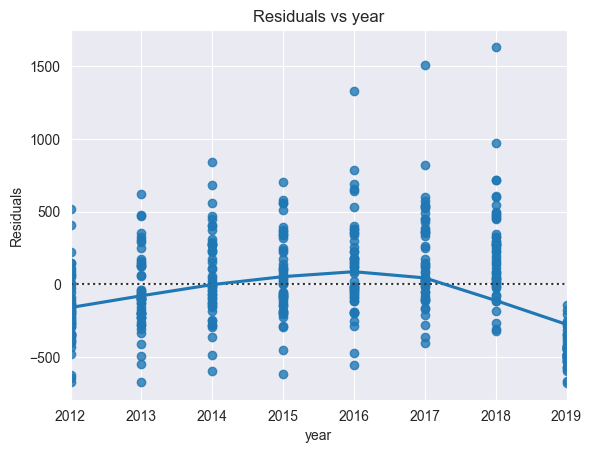

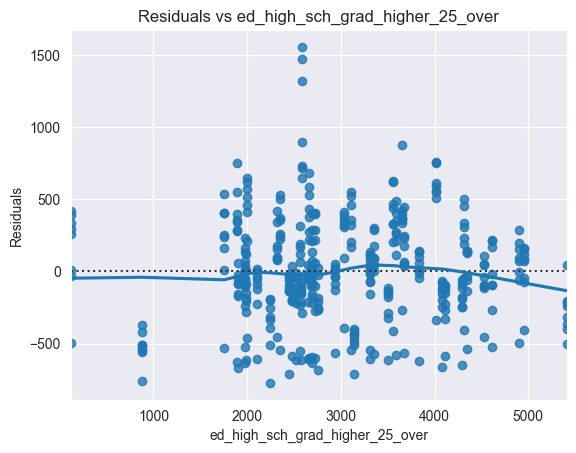

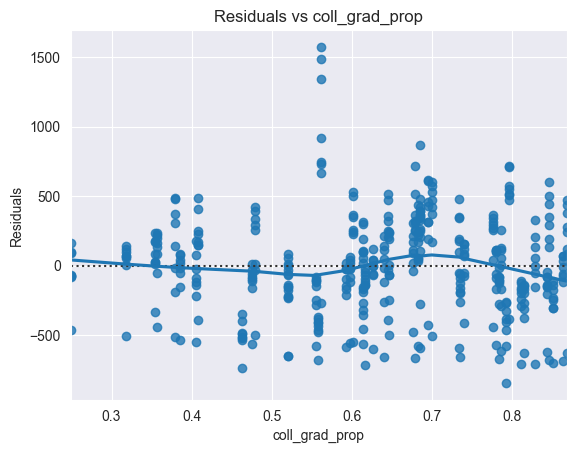

In [31]:
residuals = multi_reg.resid
x_vars = ['year', 'ed_high_sch_grad_higher_25_over', 'coll_grad_prop']

for x in x_vars:
    plt.figure()
    sns.residplot(x=data_reg[x], y=model.resid, lowess=True)
    plt.xlabel(x)
    plt.ylabel('Residuals')
    plt.title('Residuals vs ' + x)
    plt.show()

---->
1. Residuals vs Year: The residuals show a clear pattern over the period with less random scaterness and there appears to be a slight curved pattern with the residuals treading positive near the middle and negative on the sides. Which can suggest this model is not a good linear model fit and suggests that it does not fully capture the year trend in crime and the relationship needs to be further explored

2. Residuals vs ed_high_sch_grad_higher_25_over: The residuals are not evenly spread out showing a clustering pattern, especially around the different education levels. Which shows that the linear model may not fully capture the relationship between thsi education level and crime amounts. 

3. Residuals vs coll_grad_pop: These residuals are more random with no distinct pattern which can suggest a more linear-following relationship between college grad proportiond and crime.


#### (f) Thinking critically

Amidst data features like population are features like educational attainment per tract. This brings to light the fact that there may be specific demographic and socioeconomic variables/characteristics that are also associated with educational attainment. Whether intentional or not, someone looking at this data might infer a link between crime and educational attainment just due to the variables present. Even worse, someone might use the data to support harsh policing policies based on specific demographics or socioeconomic variables. Discuss, in a few paragraphs, how such datasets could be used (1) in a harmful way, and (2) in a beneficial way for society.

----> Such datasets that combine crime incidients with socioeconomic or educcational variables/characteristics can have much benefit but also carry risk. Some harmful ways the dataset could be used is misinterpreting the correlation for causation as people can falsely assume that lower educ attainment causes higher crime based off the results, when in fact this trend can be driven by larger scope conditions like poverty, socioeconomic status, employement in the area the tract is from. Likewise, these datasets could be used to reinforce certain stigma or stereotypes about a group of people based off the predictor characters. For instance, the data could be used to label certain neighborhoods as unsafe or high crime if, for instance a dataset showed high crime was heavily correlated with low hs educ grad students as that assumption will just be carried on when in fact there are other reasons most likely driving the low hs educ rates that are unrelated to crime. Moreover, areas flagged as 'high crime' by dataset inference are also at risk of defunding or denied investment which can harm the long-term growth of these areas.

However, there are also many benefits a dataset like this also comes with. For instance, analyzing the dataset to infer a linkage between crime rates and certain predictors can help to address any structural needs which can be voiced to those in charge (government, policy-makers). That, instead of putting the blame on the residents themselves, it shifts the issue to the neighborshoods as a whole that maybe are lack neccesary resources to improve the crime scene. Likewise, these types of datasets are also useful in policymakers supporting equitable policy decisions and with insights/evidence to back up claims, increases their position of securing more funding or credibility when advocating for then to higher boards (i.e. federal government). Moreover, datasets like this are also used to tell a story and can often help improve our understandings of these social issues- i.e what's the actual root causes of these crimes- and clear up any misconceptions or bias we may initially have. 